Uar xgboost par ver se o vinho e de boa qualidade

Importações

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("../dataset/winequality/winequality.csv")
df.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
5694,6.8,0.12,0.31,5.2,0.045,29.0,120.0,0.99420,3.41,0.46,9.8,7,white
5491,8.6,0.18,0.40,1.1,0.040,20.0,107.0,0.99230,2.94,0.32,10.2,7,white
2030,6.1,0.21,0.19,1.4,0.046,51.0,131.0,0.99184,3.22,0.39,10.5,5,white
3345,6.3,0.22,0.30,2.0,0.050,23.0,120.0,0.99204,3.24,0.47,10.4,6,white
5764,5.7,0.26,0.30,1.8,0.039,30.0,105.0,0.98995,3.48,0.52,12.5,7,white
4121,7.2,0.37,0.40,11.6,0.032,34.0,214.0,0.99630,3.10,0.51,9.8,6,white
3973,5.7,0.27,0.16,9.0,0.053,32.0,111.0,0.99474,3.36,0.37,10.4,6,white
5578,6.7,0.22,0.37,1.6,0.028,24.0,102.0,0.99130,3.29,0.59,11.6,7,white
2546,7.6,0.38,0.28,4.2,0.029,7.0,112.0,0.99060,3.00,0.41,12.6,6,white
2562,7.4,0.58,0.00,2.0,0.064,7.0,11.0,0.99562,3.45,0.58,11.3,6,red


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000,6492.000000
mean,7.215149,0.339698,0.318581,5.444254,0.056056,30.523105,115.744378,0.994699,3.218432,0.531319,10.490501,5.815927
std,1.296691,0.164690,0.145348,4.758579,0.035038,17.752926,56.541478,0.002997,0.160817,0.148834,1.191985,0.869114
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,8.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6492 entries, 0 to 6491
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6492 non-null   float64
 1   volatile acidity      6492 non-null   float64
 2   citric acid           6492 non-null   float64
 3   residual sugar        6492 non-null   float64
 4   chlorides             6492 non-null   float64
 5   free sulfur dioxide   6492 non-null   float64
 6   total sulfur dioxide  6492 non-null   float64
 7   density               6492 non-null   float64
 8   pH                    6492 non-null   float64
 9   sulphates             6492 non-null   float64
 10  alcohol               6492 non-null   float64
 11  quality               6492 non-null   int64  
 12  type                  6492 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 659.5+ KB


In [5]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

Correlações

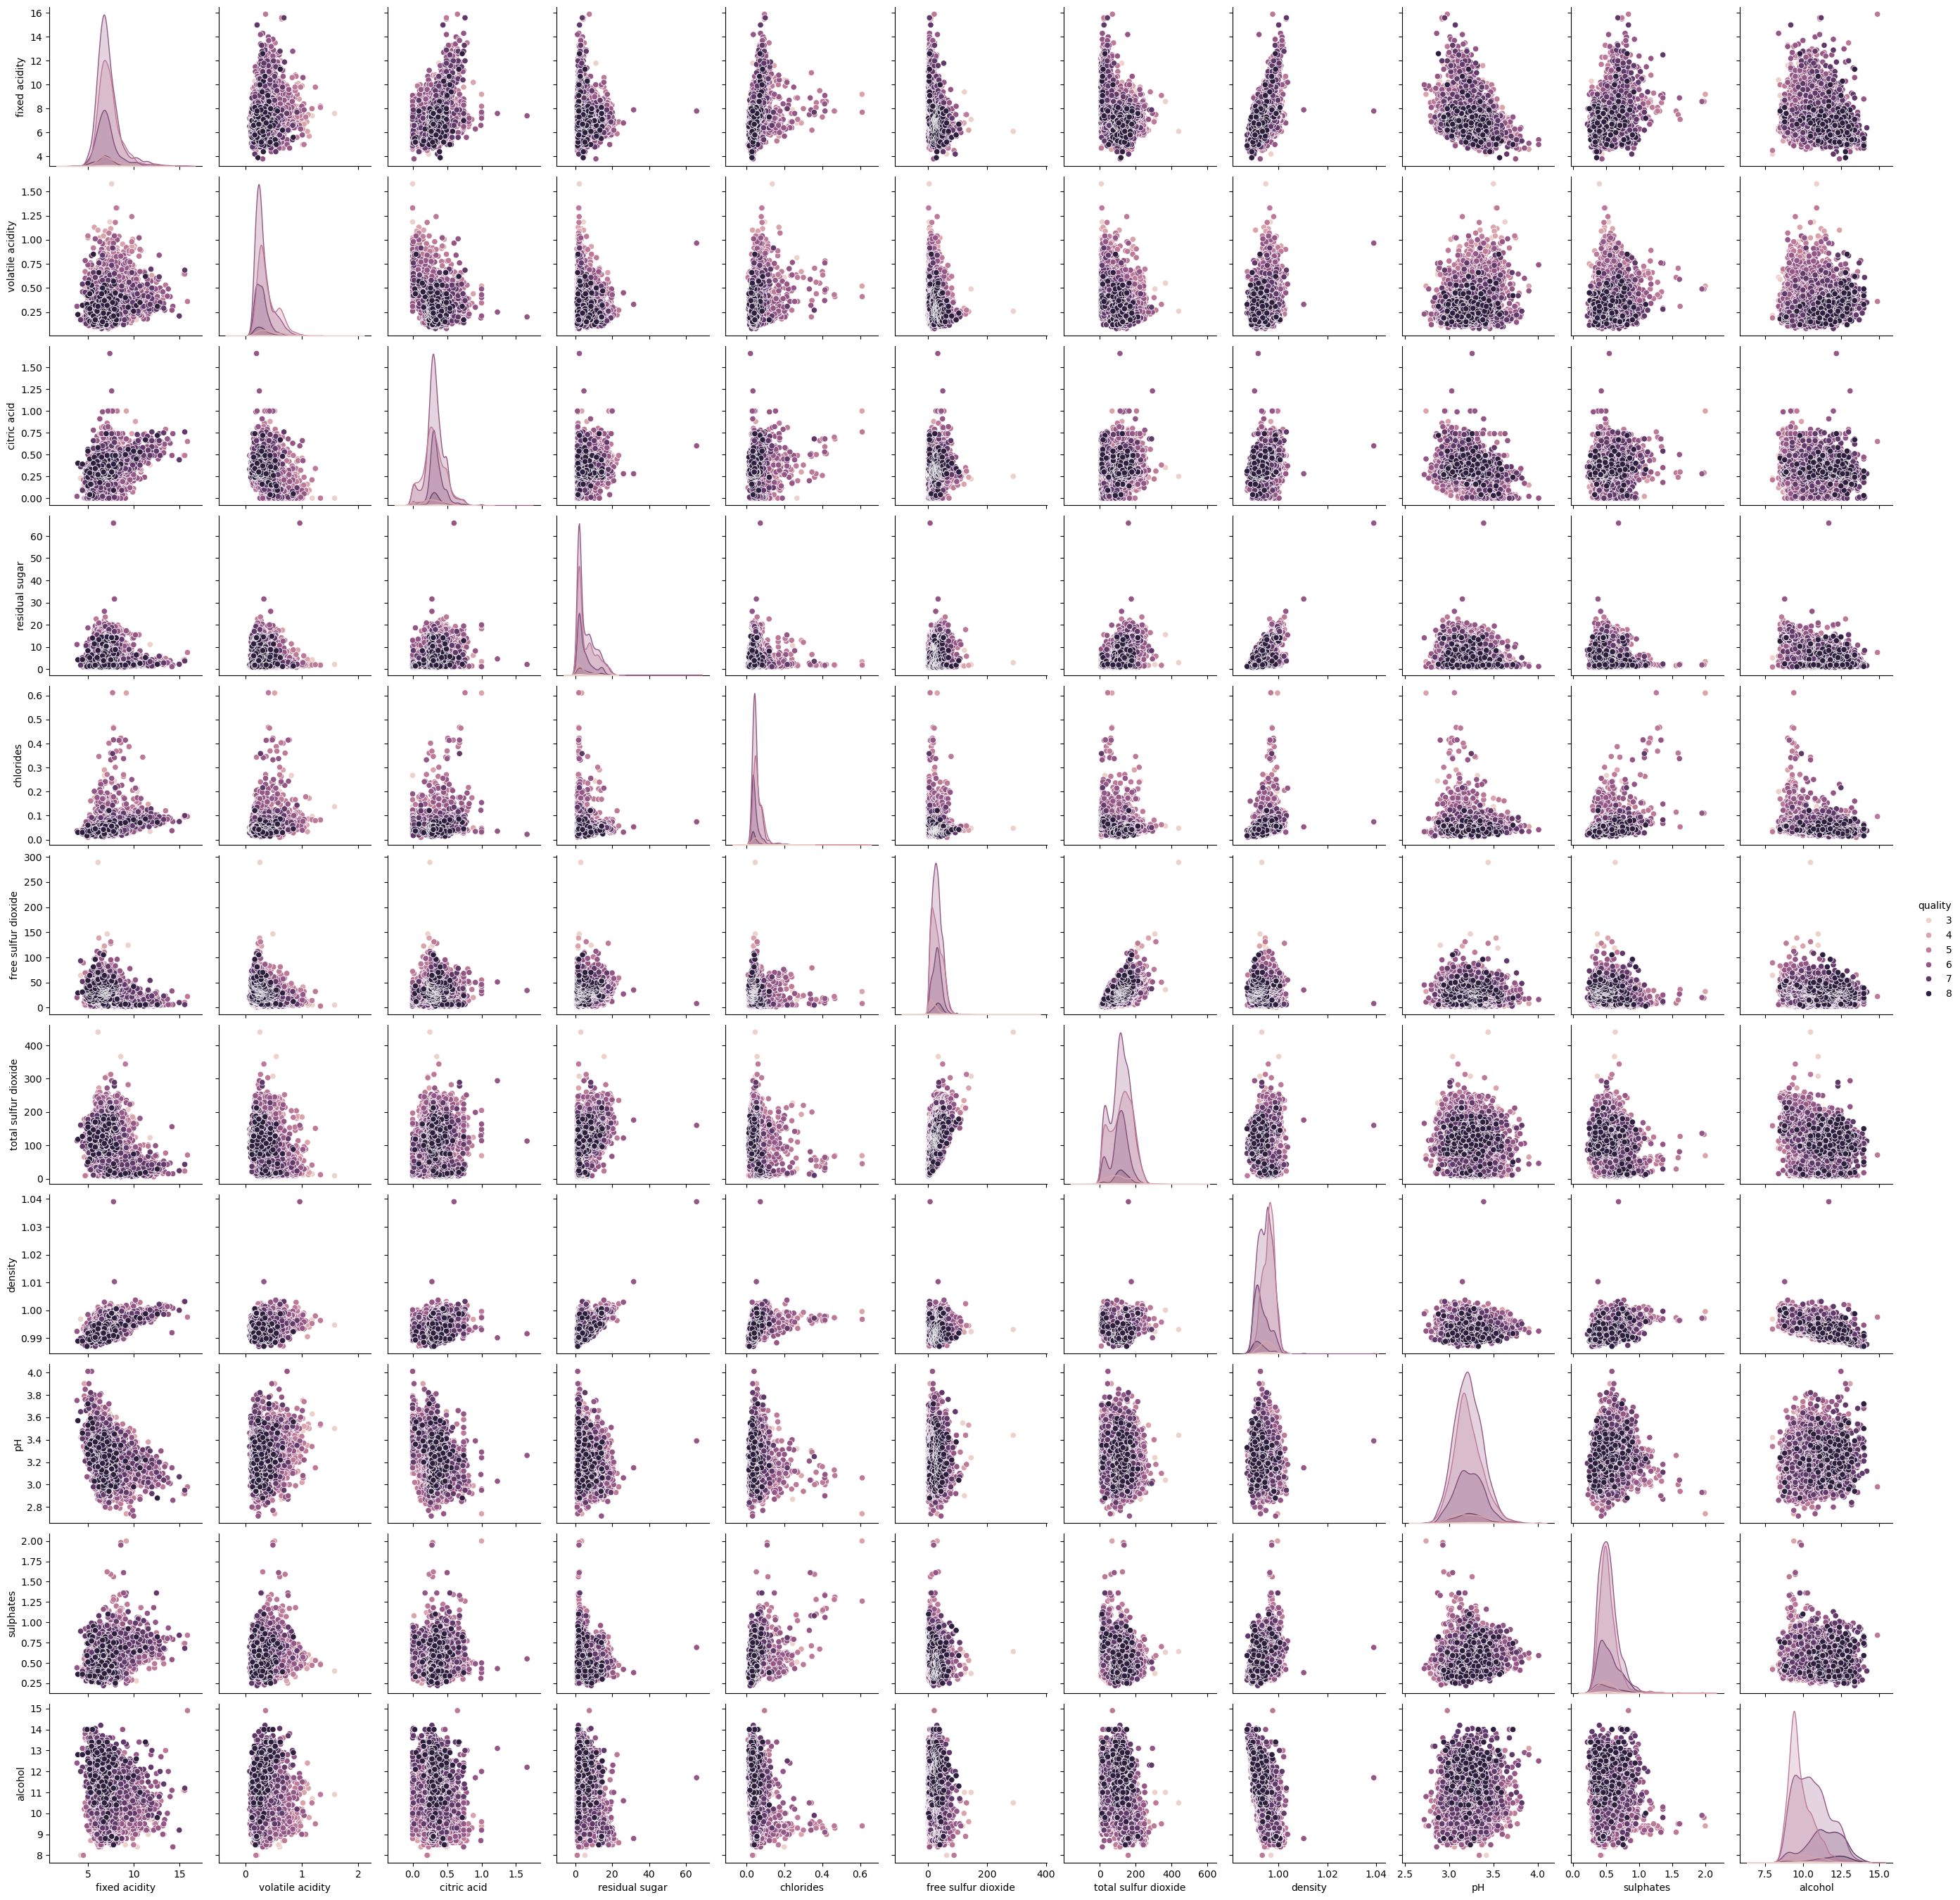

In [6]:
sns.pairplot(df, hue="quality")

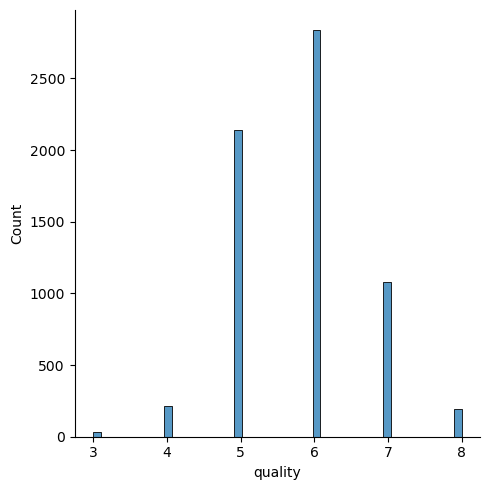

In [7]:
sns.displot(df['quality'])

Pré-Processamento

In [9]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

encoded_cols = encoder.fit_transform(df[['type']])
feature_names = encoder.get_feature_names_out(['type'])
encoded_df = pd.DataFrame(encoded_cols, columns=feature_names)

df2 = pd.concat([df, encoded_df], axis=1)
df2 = df2.drop(columns='type', axis=1)

df = df2

<Axes: >

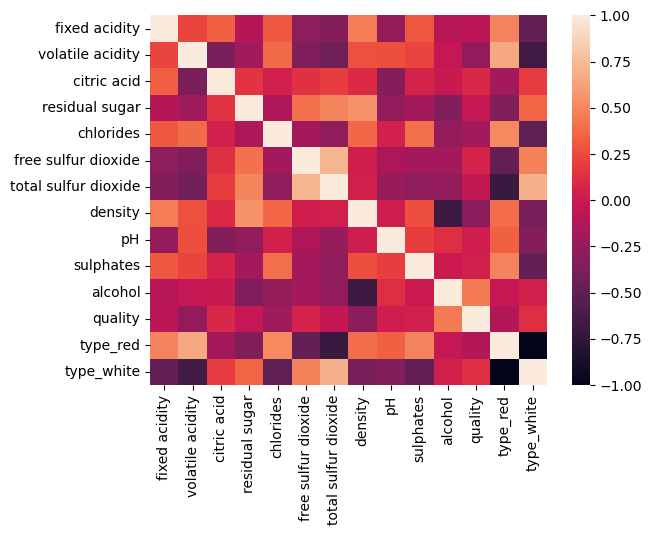

In [11]:
sns.heatmap(df.corr())